<a href="https://colab.research.google.com/github/jooyoung227/ESAA-14-23-/blob/main/weather%20data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving weather_test.csv to weather_test (1).csv
Saving weather_train.csv to weather_train (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").disabled = True

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").disabled = True

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["axes.unicode_minus"] = False

def apply_korean_font(ax=None, title=None, xlabel=None, ylabel=None, rotation_x=0, rotation_y=0):
    if ax is None:
        ax = plt.gca()

    if title is not None:
        ax.set_title(title, fontproperties=font_prop)

    if xlabel is not None:
        ax.set_xlabel(xlabel, fontproperties=font_prop)

    if ylabel is not None:
        ax.set_ylabel(ylabel, fontproperties=font_prop)

    for label in ax.get_xticklabels():
        label.set_fontproperties(font_prop)
        label.set_rotation(rotation_x)

    for label in ax.get_yticklabels():
        label.set_fontproperties(font_prop)
        label.set_rotation(rotation_y)

    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontproperties(font_prop)
        legend.get_title().set_fontproperties(font_prop)

    return ax

In [ ]:
train = pd.read_csv("weather_train.csv")
test = pd.read_csv("weather_test.csv")

# train/test 구분 컬럼 추가
train["set"] = "train"
test["set"] = "test"

# 두 파일 합치기
weather = pd.concat([train, test], ignore_index=True)

weather.head()

,지점,지점명,year,month,평균기온(°C),평균최고기온(°C),평균최저기온(°C),최고기온(°C),최저기온(°C),최고기온 나타난날(yyyymmdd),...,평균풍속(m/s),최대순간풍속(m/s),최대순간풍속풍향(deg),최대순간풍속 나타난날(yyyymmdd),월강수량합(mm),최대순간풍속_풍향_sin,최대순간풍속_풍향_cos,평균상대습도(%),data_source,set
0,310,궁촌,2000,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,AWS,train
1,310,궁촌,2001,4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,AWS,train
2,310,궁촌,2002,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,AWS,train
3,310,궁촌,2002,4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,AWS,train
4,310,궁촌,2002,5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,AWS,train


In [ ]:
print("전체 데이터 크기:", weather.shape)
print("연도 범위:", weather["year"].min(), "~", weather["year"].max())
print("관측소 수:", weather["지점명"].nunique())

weather.info()

전체 데이터 크기: (22821, 21)
연도 범위: 2000 ~ 2022
관측소 수: 95
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22821 entries, 0 to 22820
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   지점                     22821 non-null  int64  
 1   지점명                    22821 non-null  object 
 2   year                   22821 non-null  int64  
 3   month                  22821 non-null  int64  
 4   평균기온(°C)               22394 non-null  float64
 5   평균최고기온(°C)             22021 non-null  float64
 6   평균최저기온(°C)             22021 non-null  float64
 7   최고기온(°C)               22202 non-null  float64
 8   최저기온(°C)               22202 non-null  float64
 9   최고기온 나타난날(yyyymmdd)    22202 non-null  float64
 10  최저기온 나타난날(yyyymmdd)    22202 non-null  float64
 11  평균풍속(m/s)              21997 non-null  float64
 12  최대순간풍속(m/s)            22291 non-null  float64
 13  최대순간풍속풍향(deg)          22160 non-null  float64
 14  최대

전체 데이터는 22,821행, 21개 컬럼  
기간 2000년부터 2022년까지   
관측소는 총 95개

In [ ]:
weather.describe()

,지점,year,month,평균기온(°C),평균최고기온(°C),평균최저기온(°C),최고기온(°C),최저기온(°C),최고기온 나타난날(yyyymmdd),최저기온 나타난날(yyyymmdd),평균풍속(m/s),최대순간풍속(m/s),최대순간풍속풍향(deg),최대순간풍속 나타난날(yyyymmdd),월강수량합(mm),최대순간풍속_풍향_sin,최대순간풍속_풍향_cos,평균상대습도(%)
count,22821.000000,22821.000000,22821.000000,22394.000000,22021.000000,22021.000000,22202.000000,22202.000000,2.220200e+04,2.220200e+04,21997.000000,22291.000000,22160.000000,2.229100e+04,22819.000000,22160.000000,22160.000000,3432.000000
mean,521.343675,2011.584637,6.512204,10.158998,16.100400,5.140112,23.241010,-1.718660,2.011805e+07,2.011805e+07,1.819089,15.201301,216.458547,2.011785e+07,108.475091,-0.360136,-0.082235,66.261946
std,204.576560,6.497184,3.454283,9.887210,9.770227,10.414224,9.151515,11.822442,6.500687e+04,6.500689e+04,1.091044,6.244838,90.788932,6.495563e+04,140.935499,0.641899,0.671971,11.663347
min,90.000000,2000.000000,1.000000,-15.000000,-10.500000,-21.700000,-7.000000,-33.000000,2.000010e+07,2.000011e+07,0.000000,0.000000,0.000000,2.000010e+07,0.000000,-1.000000,-1.000000,32.000000
25%,517.000000,2006.000000,4.000000,1.800000,7.400000,-3.400000,15.800000,-11.000000,2.006100e+07,2.006102e+07,1.100000,11.700000,168.800000,2.006101e+07,20.500000,-0.931691,-0.707107,58.000000
50%,558.000000,2012.000000,7.000000,11.000000,17.900000,5.200000,25.200000,-1.900000,2.012080e+07,2.012081e+07,1.600000,14.200000,236.300000,2.012072e+07,57.800000,-0.596225,-0.146083,67.000000
75%,595.000000,2017.000000,10.000000,19.000000,24.700000,14.400000,31.000000,8.400000,2.017110e+07,2.017112e+07,2.200000,17.500000,280.800000,2.017111e+07,135.500000,0.059742,0.516533,75.000000
max,978.000000,2022.000000,12.000000,28.500000,34.000000,25.300000,52.200000,22.900000,2.022121e+07,2.022122e+07,12.400000,75.000000,360.000000,2.022123e+07,1416.000000,1.000000,1.000000,96.000000


In [ ]:
# 기상 위험 점수 생성
weather["temp_risk"] = weather["최고기온(°C)"].rank(pct=True)
weather["wind_risk"] = weather["최대순간풍속(m/s)"].rank(pct=True)
weather["rain_risk"] = 1 - weather["월강수량합(mm)"].rank(pct=True)

weather["weather_risk_score"] = (
    weather["temp_risk"] * 0.35 +
    weather["wind_risk"] * 0.35 +
    weather["rain_risk"] * 0.30
)

최고기온, 최대순간풍속, 월강수량합을 이용하여 weather_risk_score를 생성하였다.
점수가 높을수록 고온, 강풍, 저강수 조건이 강하게 나타나는 기상 상황으로 해석할 수 있다. 다만 이는 실제 산불 발생 여부가 아니라, 기상 조건 기반의 상대적 위험 지표이다.

###결측치 확인

In [ ]:
missing_count = weather.isnull().sum()
missing_rate = weather.isnull().mean() * 100

missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_rate(%)": missing_rate
}).sort_values("missing_rate(%)", ascending=False)

missing_df

,missing_count,missing_rate(%)
평균상대습도(%),19389,84.961220
평균풍속(m/s),824,3.610709
평균최저기온(°C),800,3.505543
평균최고기온(°C),800,3.505543
최대순간풍속_풍향_sin,661,2.896455
최대순간풍속풍향(deg),661,2.896455
최대순간풍속_풍향_cos,661,2.896455
weather_risk_score,626,2.743088
최저기온(°C),619,2.712414
temp_risk,619,2.712414


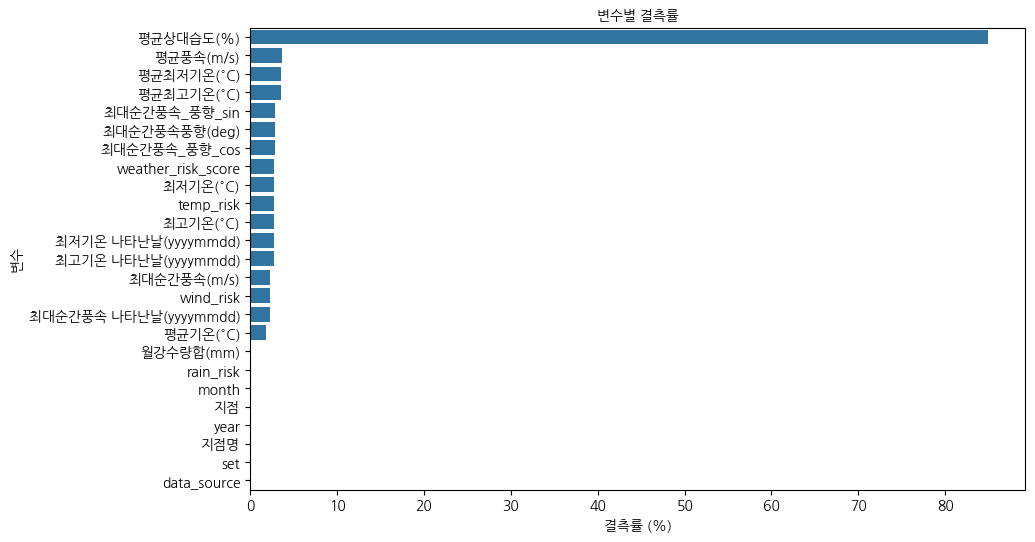

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_df["missing_rate(%)"],
    y=missing_df.index
)

plt.xlabel("결측률 (%)", fontproperties=font_prop)
plt.ylabel("변수", fontproperties=font_prop)
plt.title("변수별 결측률", fontproperties=font_prop)

# y축 눈금 한글에도 폰트 적용
plt.yticks(fontproperties=font_prop)
plt.xticks(fontproperties=font_prop)

plt.show()

변수별 결측 개수와 결측률을 확인하였다. 분석 결과, 평균상대습도(%)의 결측률이 약 85%로 매우 높게 나타났다. 따라서 습도 변수는 주요 분석 변수로 사용하기에 한계가 있으며, 이후 분석에서는 기온, 풍속, 강수량 중심으로 해석하는 것이 적절하다.

###변수별 분포 및 이상치

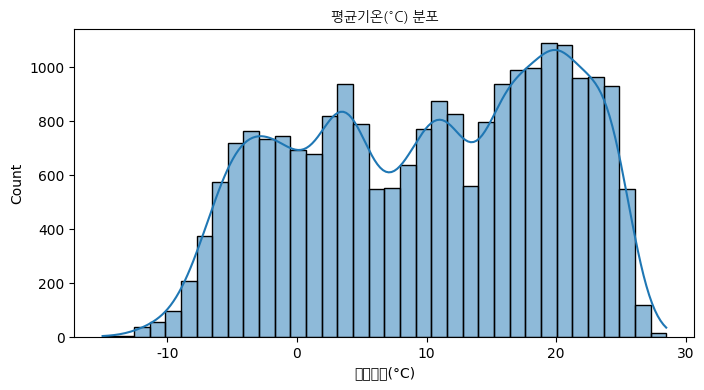

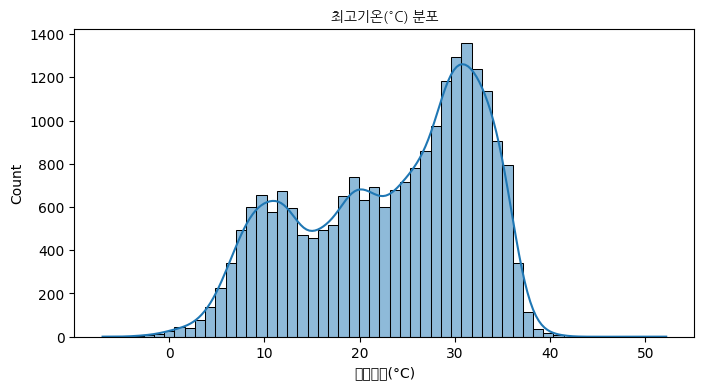

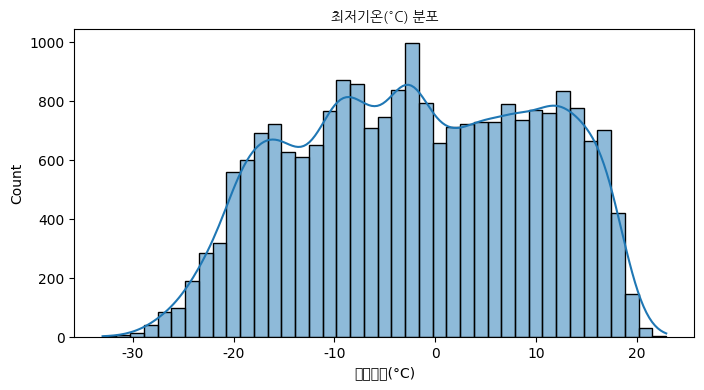

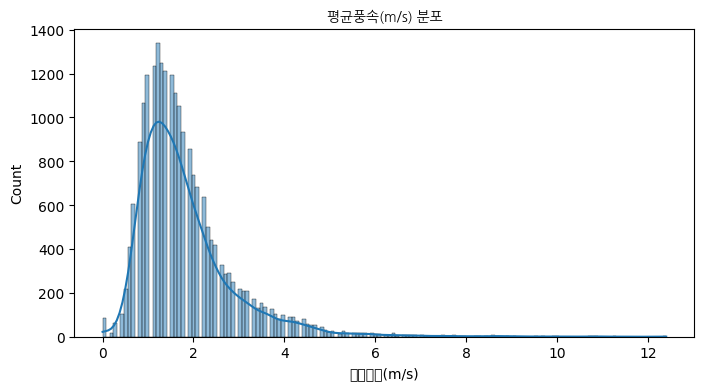

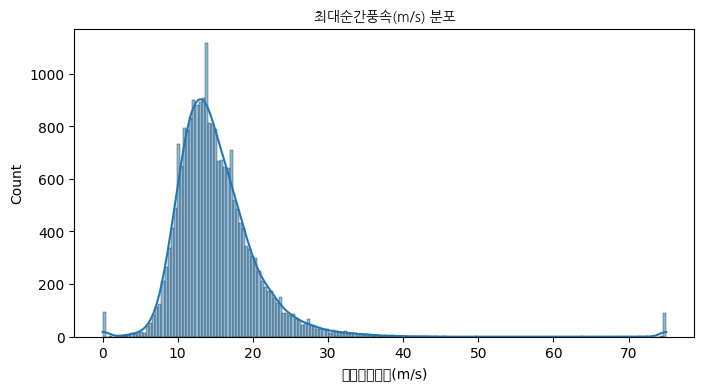

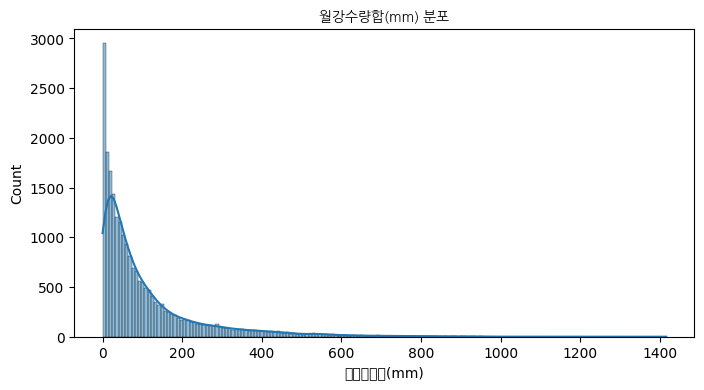

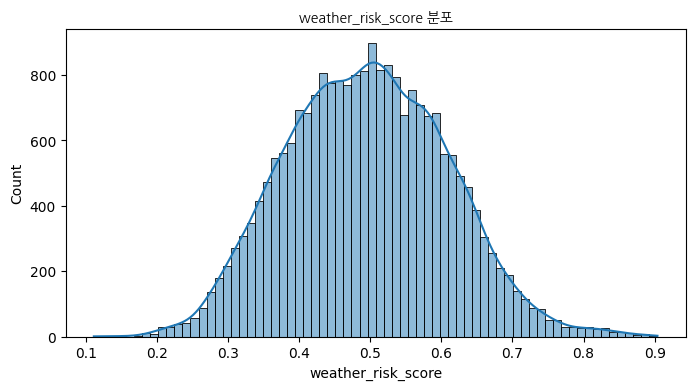

In [ ]:
eda_cols = [
    "평균기온(°C)",
    "최고기온(°C)",
    "최저기온(°C)",
    "평균풍속(m/s)",
    "최대순간풍속(m/s)",
    "월강수량합(mm)",
    "weather_risk_score"
]

for col in eda_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(weather[col], kde=True)
    plt.title(f"{col} 분포", fontproperties=font_prop)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

평균기온, 최고기온, 최저기온, 평균풍속, 최대순간풍속, 월강수량합, 기상 위험 점수의 분포를 히스토그램으로 확인하였다. 이를 통해 각 변수가 어떤 범위에 많이 분포하는지 확인할 수 있었다. 특히 강수량은 일부 큰 값이 존재해 한쪽으로 치우친 분포를 보일 가능성이 있다.

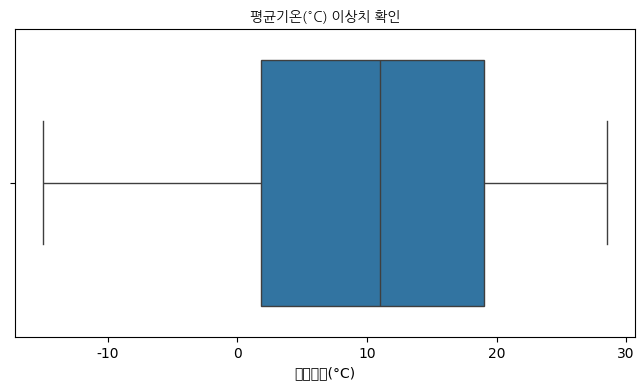

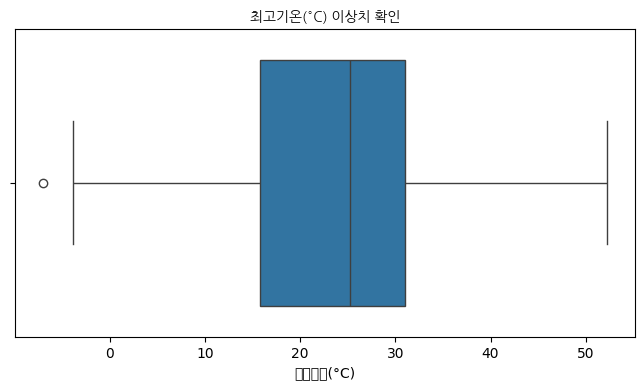

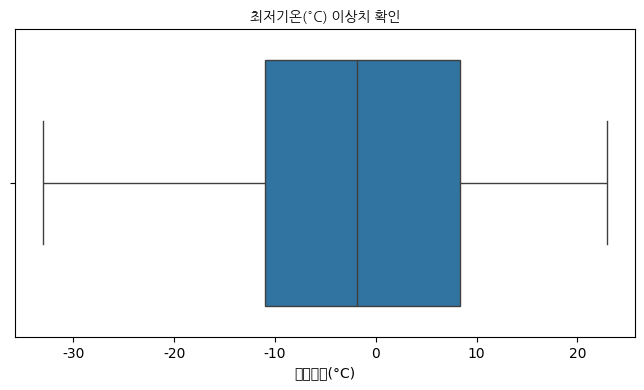

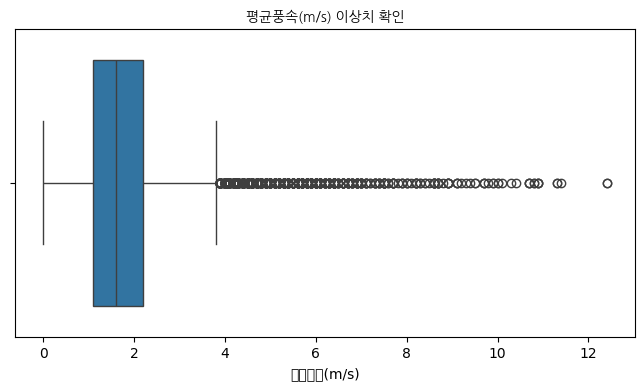

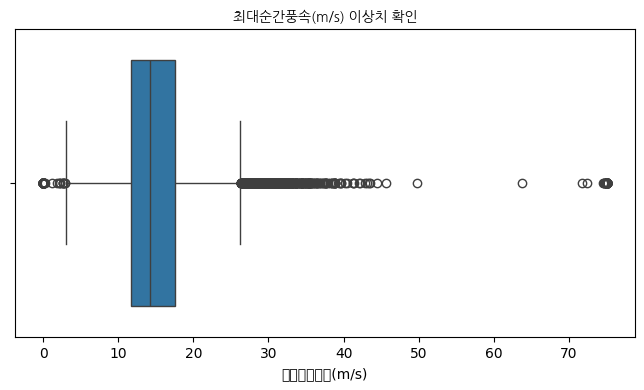

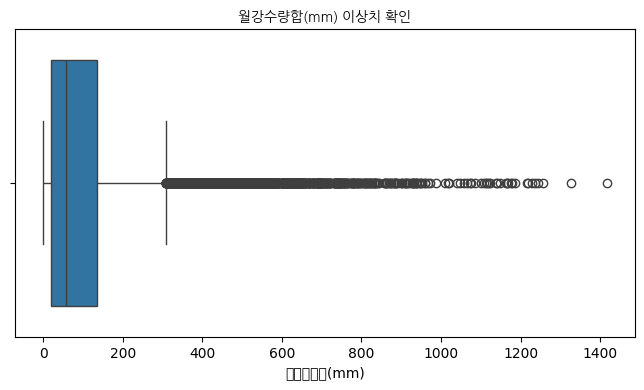

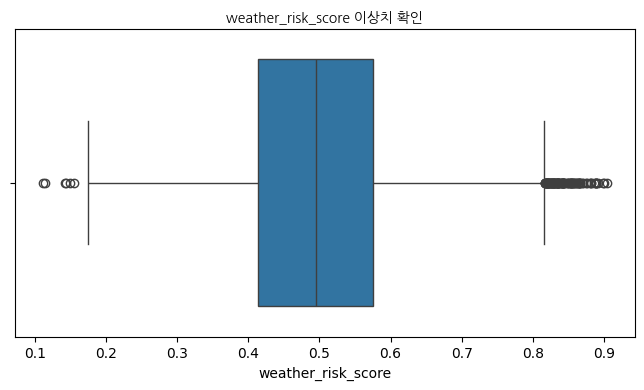

In [ ]:
for col in eda_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=weather[col])
    plt.title(f"{col} 이상치 확인", fontproperties=font_prop)
    plt.xlabel(col)
    plt.show()

박스플롯을 통해 주요 기상 변수의 이상치를 확인하였다. 기온, 풍속, 강수량에서 일부 극단값이 나타났으며, 산불 위험 분석에서는 이러한 극단적인 고온·강풍·저강수 조건이 중요한 의미를 가질 수 있으므로 단순히 제거하기보다는 별도로 해석할 필요가 있다.

###극값

In [ ]:
extreme_summary = weather[[
    "최고기온(°C)",
    "최저기온(°C)",
    "평균풍속(m/s)",
    "최대순간풍속(m/s)",
    "월강수량합(mm)",
    "평균상대습도(%)"
]].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

extreme_summary

,최고기온(°C),최저기온(°C),평균풍속(m/s),최대순간풍속(m/s),월강수량합(mm),평균상대습도(%)
count,22202.000000,22202.000000,21997.000000,22291.000000,22819.000000,3432.000000
mean,23.241010,-1.718660,1.819089,15.201301,108.475091,66.261946
std,9.151515,11.822442,1.091044,6.244838,140.935499,11.663347
min,-7.000000,-33.000000,0.000000,0.000000,0.000000,32.000000
1%,3.800000,-25.100000,0.400000,6.100000,0.000000,38.000000
5%,7.400000,-20.400000,0.700000,8.700000,1.000000,46.000000
50%,25.200000,-1.900000,1.600000,14.200000,57.800000,67.000000
95%,35.200000,16.400000,3.900000,24.200000,404.500000,84.000000
99%,36.900000,18.700000,5.800000,32.800000,657.910000,88.000000
max,52.200000,22.900000,12.400000,75.000000,1416.000000,96.000000


###월별 기온 계절성

In [ ]:
monthly_temp = weather.groupby("month")[[
    "평균기온(°C)",
    "평균최고기온(°C)",
    "평균최저기온(°C)",
    "최고기온(°C)",
    "최저기온(°C)"
]].mean()

monthly_temp

,평균기온(°C),평균최고기온(°C),평균최저기온(°C),최고기온(°C),최저기온(°C)
month,,,,,
1,-4.444216,1.424217,-9.706645,8.359978,-17.959869
2,-1.706904,4.308712,-7.212274,12.648533,-15.727935
3,3.899031,10.141771,-1.830235,19.175068,-9.285660
4,10.109496,16.851528,3.748144,25.994734,-2.597123
5,15.782842,22.483588,9.696728,29.806620,3.238850
6,19.829839,25.798086,14.895899,31.963454,8.970872
7,22.901124,27.630191,19.479292,33.080983,15.269206
8,23.111438,28.088593,19.577295,33.716793,14.126674
9,17.982513,23.813290,13.708660,29.312129,7.665067


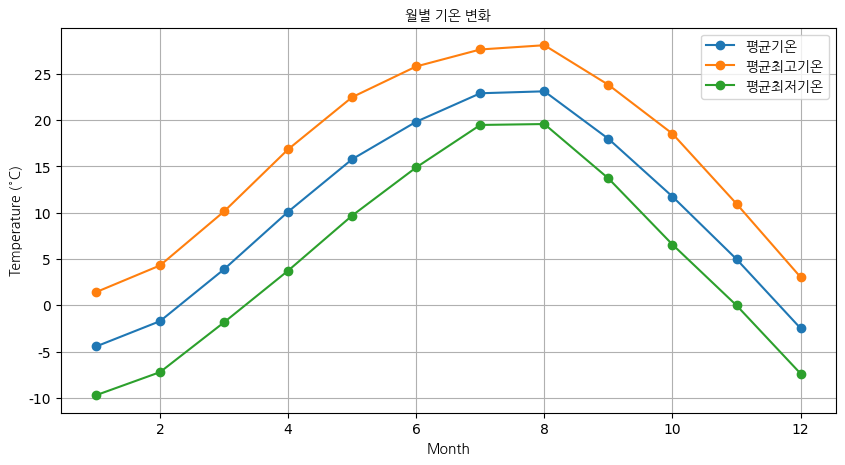

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_temp.index, monthly_temp["평균기온(°C)"], marker="o", label="평균기온")
plt.plot(monthly_temp.index, monthly_temp["평균최고기온(°C)"], marker="o", label="평균최고기온")
plt.plot(monthly_temp.index, monthly_temp["평균최저기온(°C)"], marker="o", label="평균최저기온")
plt.xlabel("Month", fontproperties=font_prop)
plt.ylabel("Temperature (°C)", fontproperties=font_prop)
plt.title("월별 기온 변화", fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.grid()
plt.show()

###월별 풍속 계절성

In [ ]:
monthly_wind = weather.groupby("month")[[
    "평균풍속(m/s)",
    "최대순간풍속(m/s)"
]].mean()

monthly_wind

,평균풍속(m/s),최대순간풍속(m/s)
month,,
1,1.952035,15.637175
2,2.006096,15.227474
3,2.126108,16.815135
4,2.236592,17.106861
5,1.997540,16.437689
6,1.612685,13.215866
7,1.534536,13.506095
8,1.478913,14.108518
9,1.449809,13.908670


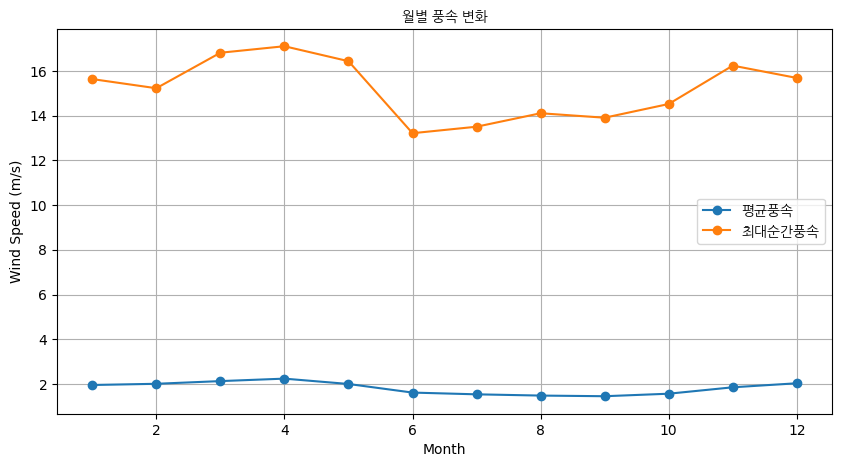

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_wind.index, monthly_wind["평균풍속(m/s)"], marker="o", label="평균풍속")
plt.plot(monthly_wind.index, monthly_wind["최대순간풍속(m/s)"], marker="o", label="최대순간풍속")
plt.xlabel("Month")
plt.ylabel("Wind Speed (m/s)")
plt.title("월별 풍속 변화", fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.grid()
plt.show()

월별 평균풍속과 최대순간풍속을 확인하였다. 평균풍속과 최대순간풍속은 3~5월, 11~12월 부근에서 상대적으로 높게 나타나는 경향이 있었다. 산불은 강풍 조건에서 확산 위험이 커지기 때문에 풍속 변수는 중요한 분석 요소로 볼 수 있다.

###풍향 분포

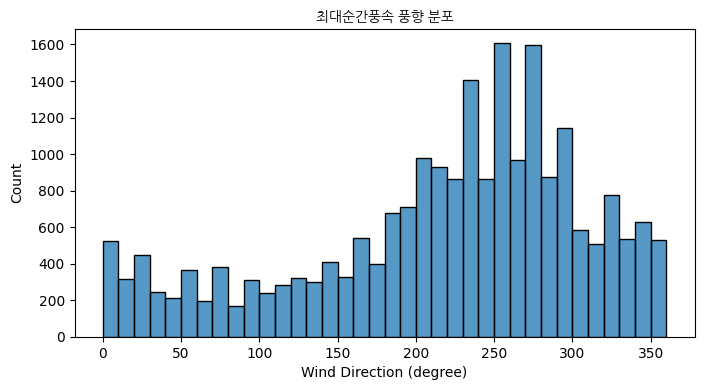

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(weather["최대순간풍속풍향(deg)"], bins=36)
plt.xlabel("Wind Direction (degree)")
plt.ylabel("Count")
plt.title("최대순간풍속 풍향 분포",  fontproperties=font_prop)
plt.show()

최대순간풍속의 풍향 분포를 확인한 결과, 240°~290° 부근에서 빈도가 높게 나타났다. 이는 강한 바람이 발생할 때 주로 서풍 계열의 바람이 많이 관측되었음을 의미한다. 다.

###월별 강수량 계절성

In [ ]:
monthly_rain = weather.groupby("month")["월강수량합(mm)"].mean()

monthly_rain

,월강수량합(mm)
month,
1,20.914286
2,27.070877
3,45.945776
4,74.460348
5,81.539863
6,125.822538
7,325.123452
8,284.149842
9,170.198736


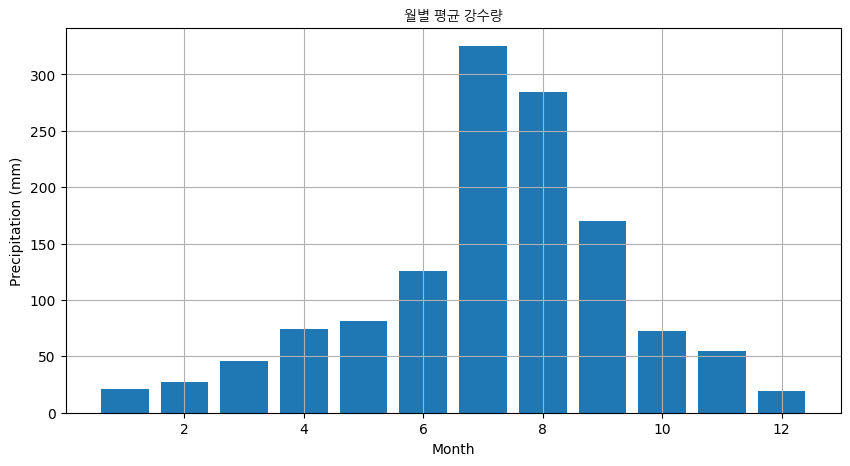

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(monthly_rain.index, monthly_rain)
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.title("월별 평균 강수량", fontproperties=font_prop)
plt.grid()
plt.show()

월별 평균 강수량을 확인한 결과, 7~8월에 강수량이 크게 증가하는 경향이 나타났다. 반대로 겨울과 초봄에는 강수량이 낮게 나타나 건조 조건이 형성될 가능성이 있다. 이는 산불 위험 기상 조건을 해석하는 데 중요한 기준이 된다.

###Moran’s I

In [ ]:
!pip install geopandas libpysal esda

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
from libpysal.weights import KNN
from esda.moran import Moran

공간 자기상관 분석을 위해 geopandas, libpysal, esda 라이브러리를 설치하고 불러왔다. 다만 현재 데이터에는 관측소의 위도·경도 좌표가 포함되어 있지 않기 때문에 Moran’s I, LISA, Getis-Ord Gi* 분석은 실제로 수행하지 않았다. 해당 분석은 추후 좌표 데이터와 결합한 뒤 진행할 수 있다.

###기상 위험 점수

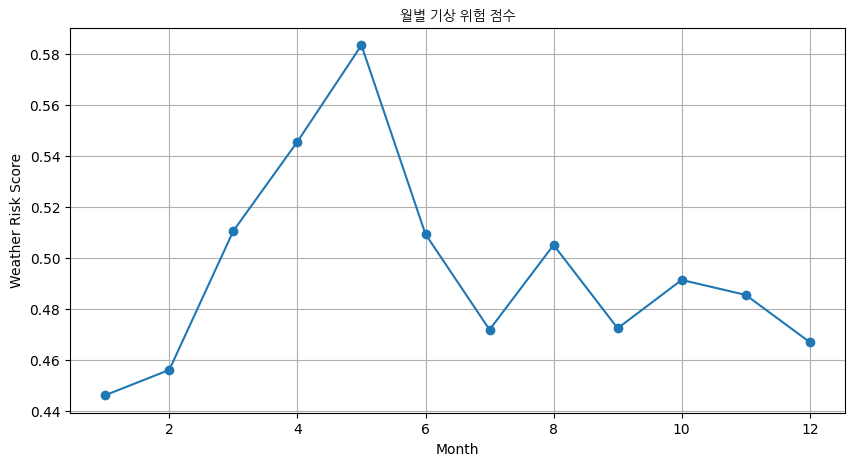

In [ ]:
# 월별 평균 기상 위험 점수
monthly_risk = weather.groupby("month")["weather_risk_score"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_risk.index, monthly_risk, marker="o")
plt.xlabel("Month")
plt.ylabel("Weather Risk Score")
plt.title("월별 기상 위험 점수", fontproperties=font_prop)
plt.grid()
plt.show()

In [ ]:
# 관측소별 평균 기상 위험 점수
station_risk = weather.groupby(["지점", "지점명"], as_index=False)["weather_risk_score"].mean()
station_risk = station_risk.sort_values("weather_risk_score", ascending=False)

display(station_risk.head(20))

,지점,지점명,weather_risk_score
20,348,하조대,0.611765
54,580,옥계,0.597813
13,217,정선군,0.594929
76,674,사북,0.589123
41,553,죽정,0.582541
42,554,미시령,0.581841
93,879,스키점프,0.581494
87,873,원주백운산,0.574703
78,677,달방댐,0.573995
36,529,원덕,0.567307


위험도가 높은 관측소 상위 20개

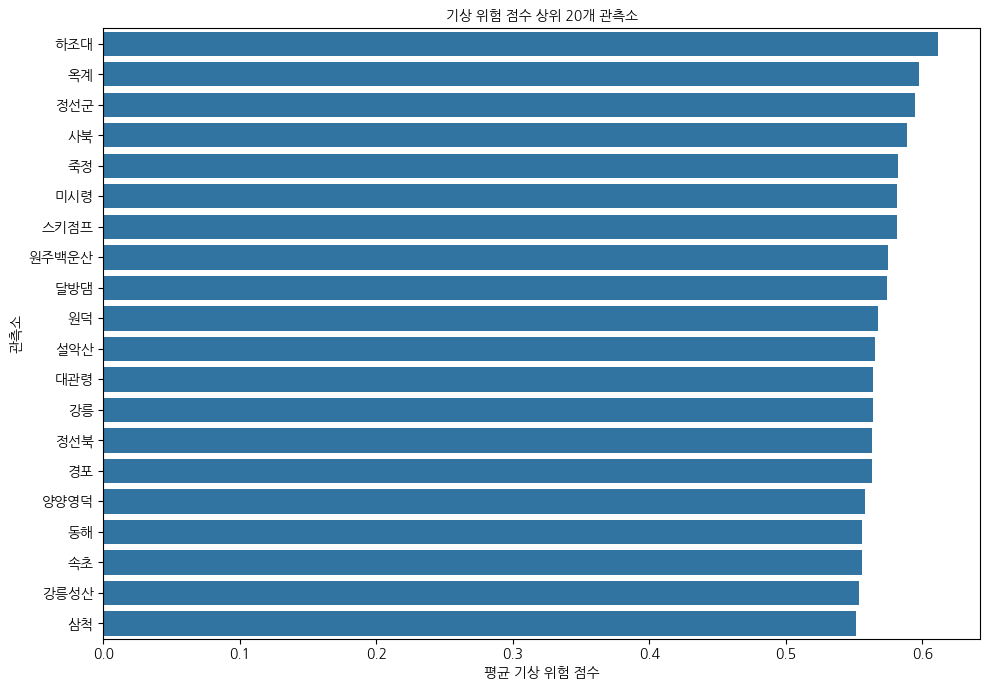

In [ ]:
station_risk = weather.groupby("지점명")["weather_risk_score"].mean().sort_values(ascending=False).reset_index()

top20_station = station_risk.head(20)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top20_station,
    x="weather_risk_score",
    y="지점명"
)

# 제목, 축 이름 한글 폰트 적용
ax.set_title("기상 위험 점수 상위 20개 관측소", fontproperties=font_prop)
ax.set_xlabel("평균 기상 위험 점수", fontproperties=font_prop)
ax.set_ylabel("관측소", fontproperties=font_prop)

# x축, y축 눈금에도 한글 폰트 적용
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontproperties=font_prop
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontproperties=font_prop
)

plt.tight_layout()
plt.show()

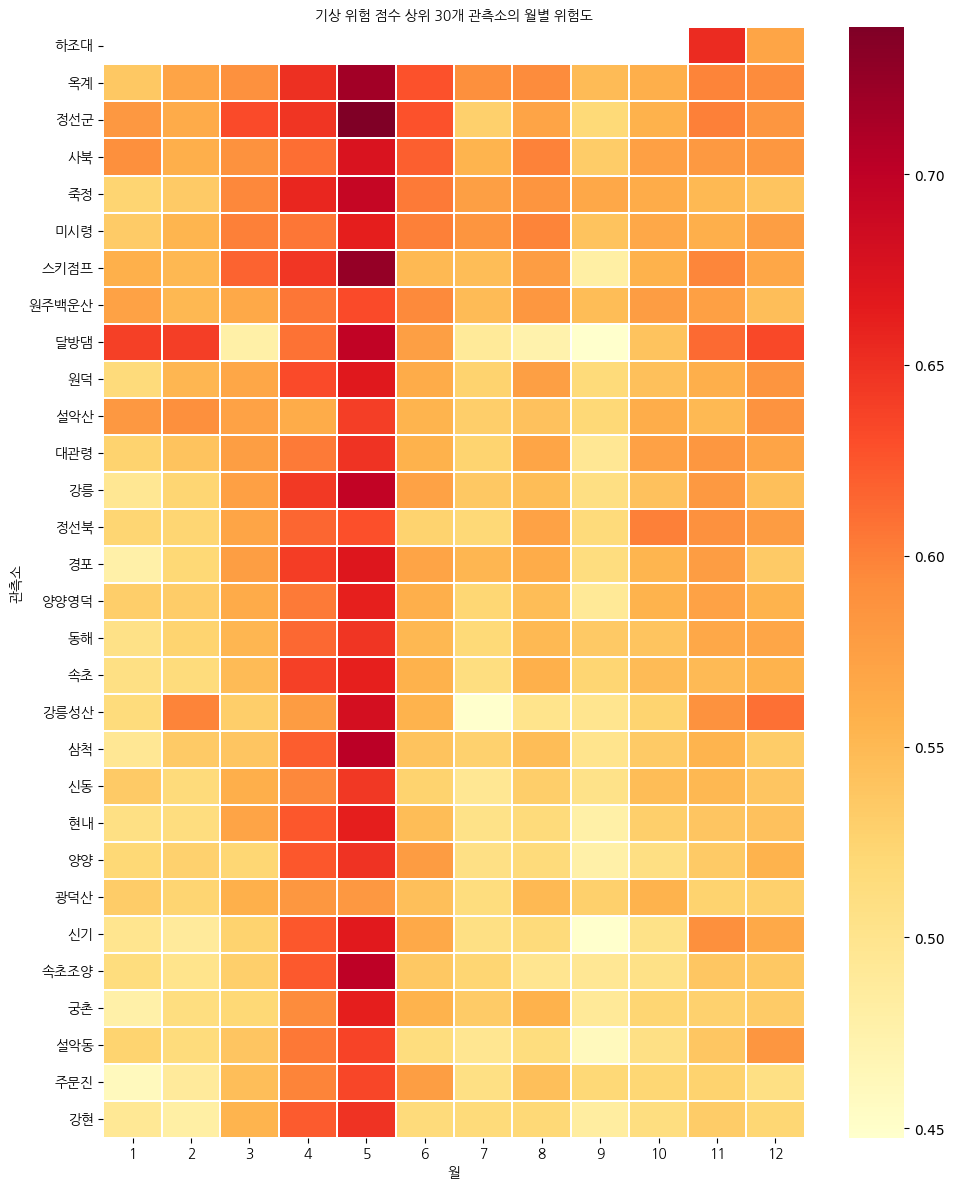

In [ ]:
# 관측소별 평균 위험도 상위 30개 선택
station_mean_risk = weather.groupby("지점명")["weather_risk_score"].mean().sort_values(ascending=False)
top30_stations = station_mean_risk.head(30).index

weather_top30 = weather[weather["지점명"].isin(top30_stations)]

# 관측소-월별 평균 위험점수
station_month_risk_top30 = weather_top30.pivot_table(
    index="지점명",
    columns="month",
    values="weather_risk_score",
    aggfunc="mean"
)

# 위험도 높은 순서로 정렬
station_month_risk_top30 = station_month_risk_top30.loc[top30_stations]

plt.figure(figsize=(10, 12))

ax = sns.heatmap(
    station_month_risk_top30,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white"
)

apply_korean_font(
    ax=ax,
    title="기상 위험 점수 상위 30개 관측소의 월별 위험도",
    xlabel="월",
    ylabel="관측소"
)

plt.tight_layout()
plt.show()

###위험 등급

In [ ]:
weather["weather_risk_grade"] = pd.qcut(
    weather["weather_risk_score"],
    q=4,
    labels=["낮음", "보통", "높음", "매우 높음"]
)

weather[[
    "지점명", "year", "month",
    "weather_risk_score", "weather_risk_grade"
]].head(20)

,지점명,year,month,weather_risk_score,weather_risk_grade
0,궁촌,2000,1,NaN,NaN
1,궁촌,2001,4,NaN,NaN
2,궁촌,2002,1,NaN,NaN
3,궁촌,2002,4,NaN,NaN
4,궁촌,2002,5,NaN,NaN
5,궁촌,2005,6,0.531950,높음
6,궁촌,2005,7,0.586653,매우 높음
7,궁촌,2005,8,0.663954,매우 높음
8,궁촌,2005,9,0.630455,매우 높음
9,궁촌,2005,10,0.650726,매우 높음


weather_risk_score를 기준으로 낮음, 보통, 높음, 매우 높음의 4단계 위험등급을 생성하였다. 이 등급은 절대적인 산불 위험등급이 아니라, 전체 데이터 안에서 위험 점수를 4분위로 나눈 상대적 기상 위험 등급이다.

In [ ]:
high_risk = weather[weather["weather_risk_grade"] == "매우 높음"]

high_risk[[
    "지점명", "year", "month",
    "최고기온(°C)",
    "최대순간풍속(m/s)",
    "월강수량합(mm)",
    "weather_risk_score",
    "weather_risk_grade"
]].head(20)

,지점명,year,month,최고기온(°C),최대순간풍속(m/s),월강수량합(mm),weather_risk_score,weather_risk_grade
6,궁촌,2005,7,32.5,15.9,143.0,0.586653,매우 높음
7,궁촌,2005,8,35.7,17.3,151.5,0.663954,매우 높음
8,궁촌,2005,9,33.4,20.8,421.5,0.630455,매우 높음
9,궁촌,2005,10,25.5,22.8,60.0,0.650726,매우 높음
10,궁촌,2005,11,20.5,24.5,3.0,0.740446,매우 높음
11,궁촌,2005,12,10.6,19.4,0.0,0.634319,매우 높음
13,궁촌,2006,2,15.2,19.5,8.5,0.639622,매우 높음
14,궁촌,2006,3,19.1,30.3,8.0,0.721118,매우 높음
15,궁촌,2006,4,23.4,29.9,77.5,0.624379,매우 높음
16,궁촌,2006,5,28.0,18.6,62.5,0.634942,매우 높음


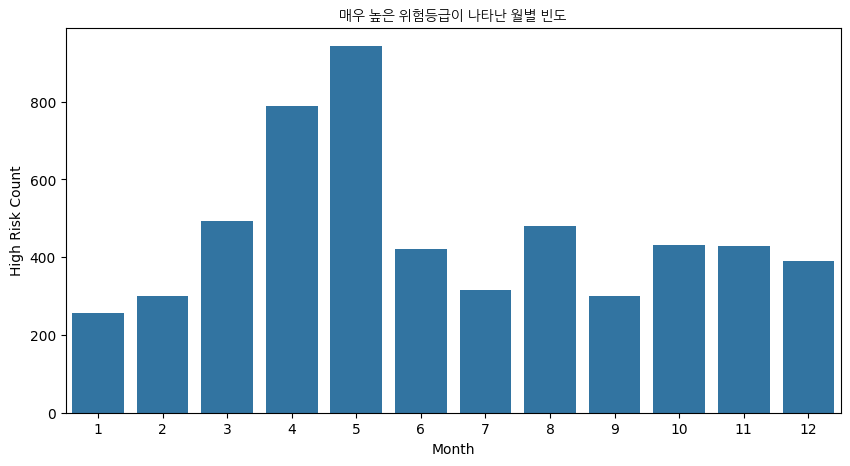

In [ ]:
high_risk_month = high_risk["month"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(
    x=high_risk_month.index,
    y=high_risk_month.values
)
plt.xlabel("Month")
plt.ylabel("High Risk Count")
plt.title("매우 높은 위험등급이 나타난 월별 빈도", fontproperties=font_prop)
plt.show()

위험등급이 매우 높음인 데이터만 따로 추출하였다. 해당 데이터들은 대체로 높은 기온, 강한 순간풍속, 낮은 강수량 조건을 포함하고 있어 기상 위험 점수가 높게 산출된 것으로 볼 수 있다. 월별 빈도 그래프를 통해 고위험 조건이 봄철인 4, 5월에 자주 나타나는 것도 확인 가능하다.

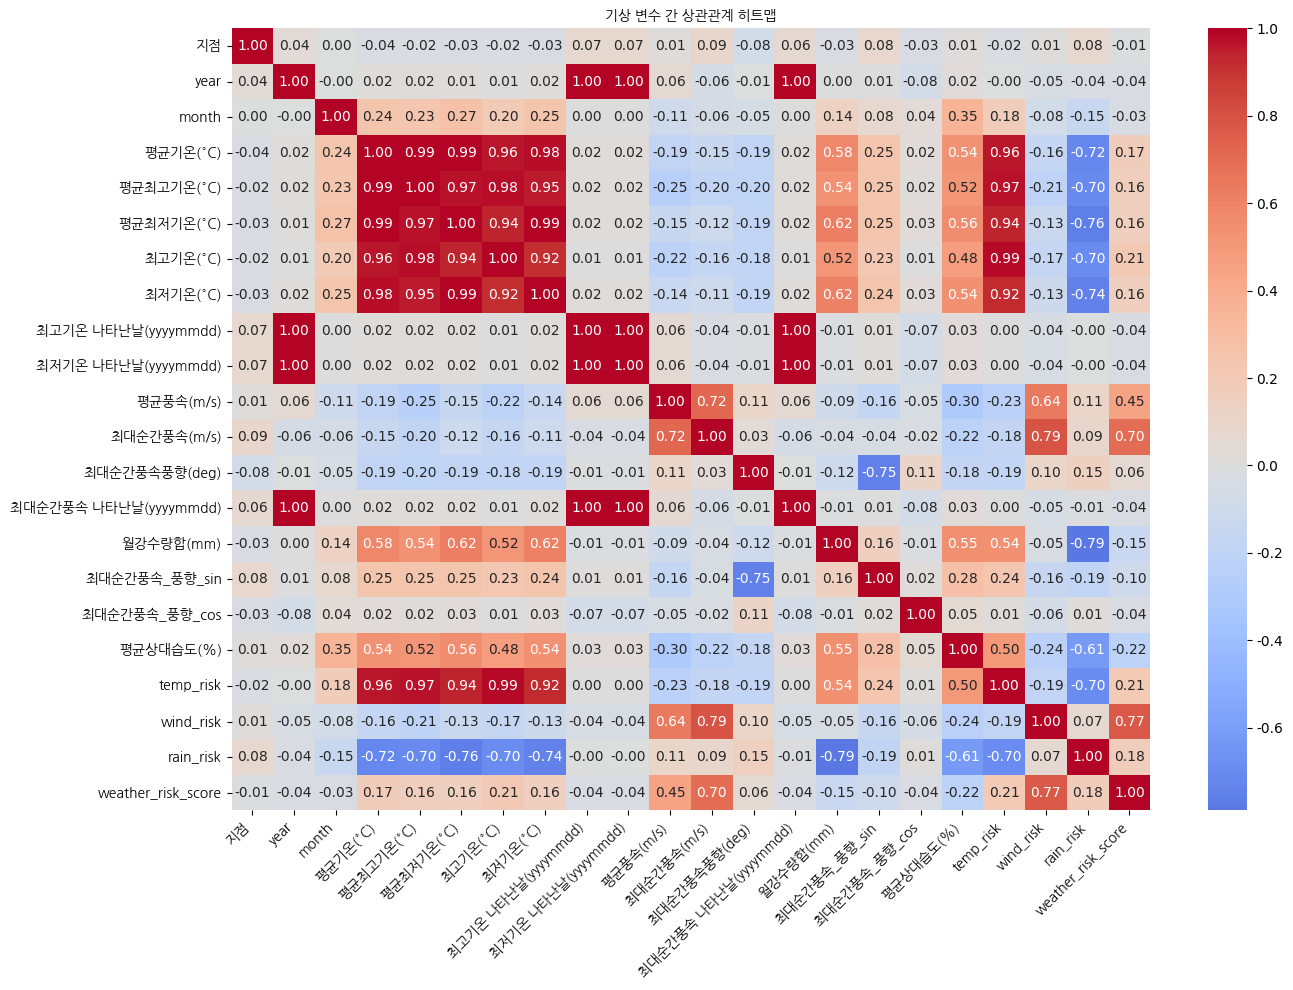

In [ ]:
# 숫자형 변수들 상관관계 히트맵
numeric_cols = weather.select_dtypes(include=["int64", "float64"]).columns

corr = weather[numeric_cols].corr()

plt.figure(figsize=(14, 10))

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

# 제목
ax.set_title("기상 변수 간 상관관계 히트맵", fontproperties=font_prop)

# x축/y축 컬럼명 한글 폰트 적용
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontproperties=font_prop,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontproperties=font_prop,
    rotation=0
)

plt.tight_layout()
plt.show()

숫자형 변수들 간 상관관계를 히트맵으로 확인하였다. 기온 관련 변수들은 서로 높은 양의 상관관계를 보였으며, 풍속 관련 변수들도 서로 관련성이 나타났다.

In [ ]:
risk_corr = weather[numeric_cols].corr()["weather_risk_score"].sort_values(ascending=False)

risk_corr

,weather_risk_score
weather_risk_score,1.000000
wind_risk,0.766339
최대순간풍속(m/s),0.696419
평균풍속(m/s),0.446665
최고기온(°C),0.211106
temp_risk,0.205020
rain_risk,0.175879
평균기온(°C),0.170376
평균최고기온(°C),0.161623
평균최저기온(°C),0.160012


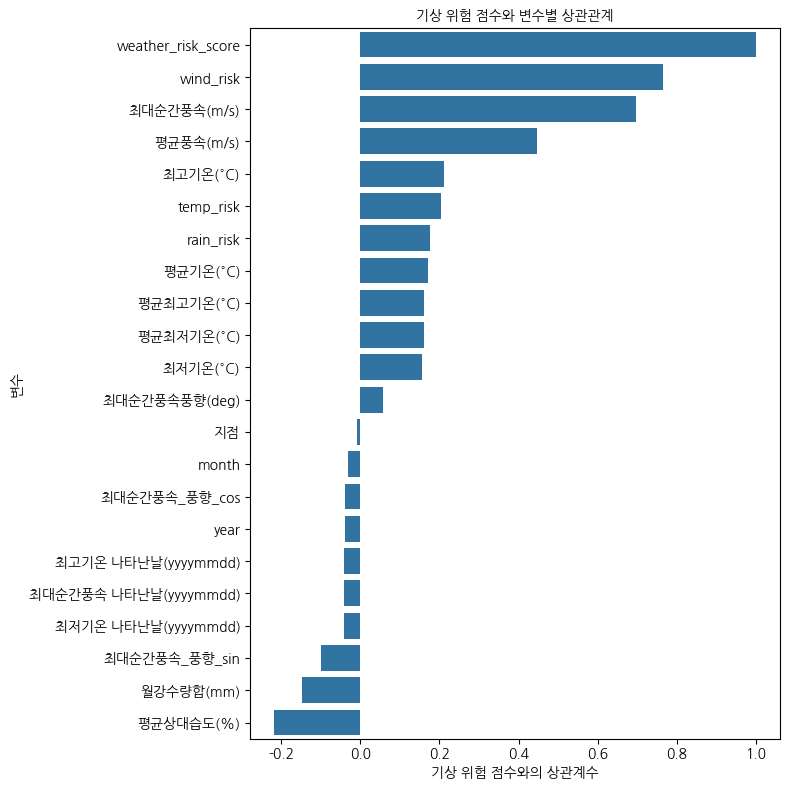

In [ ]:
plt.figure(figsize=(8, 8))

ax = sns.barplot(
    x=risk_corr.values,
    y=risk_corr.index
)

# 제목, 축 이름 한글 폰트 적용
ax.set_title("기상 위험 점수와 변수별 상관관계", fontproperties=font_prop)
ax.set_xlabel("기상 위험 점수와의 상관계수", fontproperties=font_prop)
ax.set_ylabel("변수", fontproperties=font_prop)

# x축, y축 눈금에도 한글 폰트 적용
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontproperties=font_prop
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontproperties=font_prop
)

plt.tight_layout()
plt.show()

weather_risk_score와 다른 변수들의 상관관계를 확인하였다. 위험 점수는 특히 wind_risk, 최대순간풍속, 평균풍속과 높은 상관관계를 보였다. 이는 현재 위험 점수에서 풍속 조건이 큰 영향을 미치고 있음을 보여준다.

###Train/Test 비교

In [ ]:
set_summary = weather.groupby("set")[[
    "평균기온(°C)",
    "최고기온(°C)",
    "평균풍속(m/s)",
    "최대순간풍속(m/s)",
    "월강수량합(mm)",
    "weather_risk_score"
]].mean()

set_summary

,평균기온(°C),최고기온(°C),평균풍속(m/s),최대순간풍속(m/s),월강수량합(mm),weather_risk_score
set,,,,,,
test,10.480776,23.446011,1.879409,14.899349,113.489594,0.494400
train,10.029703,23.156976,1.794332,15.324381,106.495770,0.495864


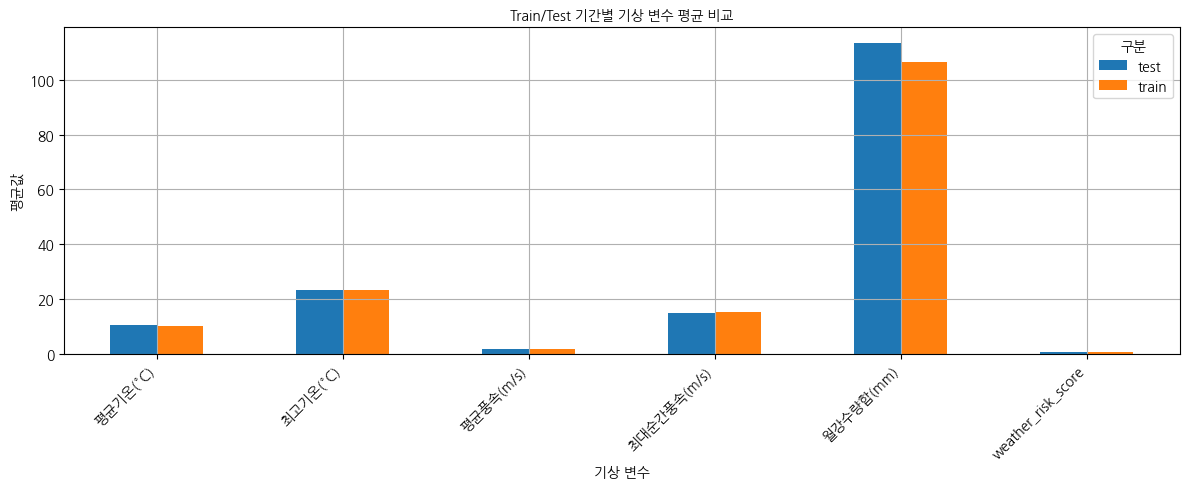

In [ ]:
ax = set_summary.T.plot(kind="bar", figsize=(12, 5))

# 제목, 축 이름 한글 폰트 적용
ax.set_title("Train/Test 기간별 기상 변수 평균 비교", fontproperties=font_prop)
ax.set_ylabel("평균값", fontproperties=font_prop)
ax.set_xlabel("기상 변수", fontproperties=font_prop)

# x축, y축 눈금 폰트 적용
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontproperties=font_prop,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontproperties=font_prop
)

# 범례 폰트 적용
legend = ax.get_legend()
if legend is not None:
    legend.set_title("구분", prop=font_prop)
    for text in legend.get_texts():
        text.set_fontproperties(font_prop)

plt.grid()
plt.tight_layout()
plt.show()

train 기간과 test 기간의 주요 기상 변수 평균을 비교하였다. 평균기온과 최고기온은 test 기간에서 약간 높게 나타났고, 월강수량도 test 기간에서 다소 높게 나타났다. 반면 전체적인 기상 위험 점수는 train과 test 간 큰 차이는 크지 않았다.

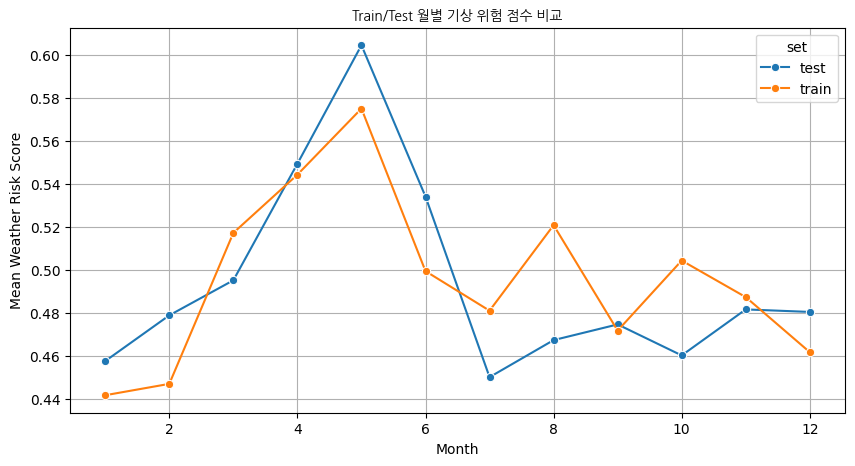

In [ ]:
monthly_set_risk = weather.groupby(["set", "month"])["weather_risk_score"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_set_risk,
    x="month",
    y="weather_risk_score",
    hue="set",
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Mean Weather Risk Score")
plt.title("Train/Test 월별 기상 위험 점수 비교", fontproperties=font_prop)
plt.grid()
plt.show()

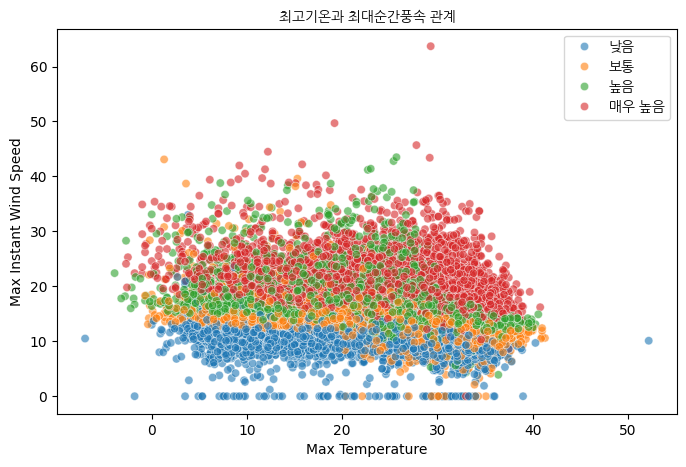

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=weather,
    x="최고기온(°C)",
    y="최대순간풍속(m/s)",
    hue="weather_risk_grade",
    alpha=0.6
)
plt.xlabel("Max Temperature")
plt.ylabel("Max Instant Wind Speed")
plt.title("최고기온과 최대순간풍속 관계", fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.show()

최고기온과 최대순간풍속의 관계를 산점도로 확인하고, 위험등급별로 색을 구분하였다. 고온과 강풍 조건이 함께 나타나는 데이터는 상대적으로 높은 위험등급에 포함될 가능성이 있다.

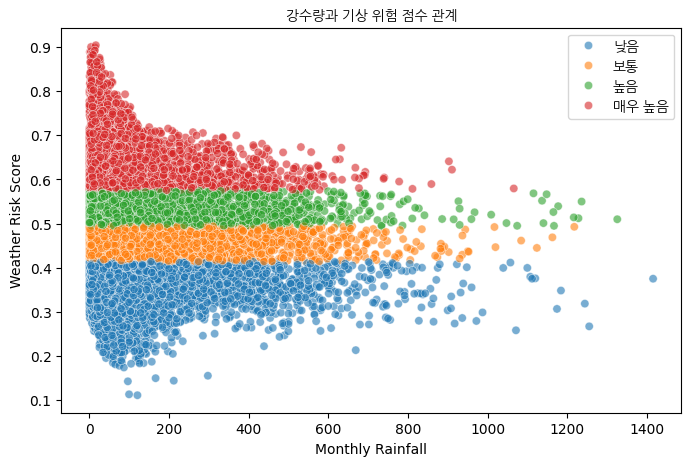

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=weather,
    x="월강수량합(mm)",
    y="weather_risk_score",
    hue="weather_risk_grade",
    alpha=0.6
)
plt.xlabel("Monthly Rainfall")
plt.ylabel("Weather Risk Score")
plt.title("강수량과 기상 위험 점수 관계", fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.show()

월강수량합과 기상 위험 점수의 관계를 산점도로 확인하였다. 강수량이 낮을수록 위험 점수가 높아지는 경향을 확인할 수 있으며, 이는 저강수 조건이 기상 위험 점수 산출에 반영되었기 때문이다.

##산불 발생 위치 파일과 합쳐보기

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 산불_좌표_OCCRR_TM.xlsx to 산불_좌표_OCCRR_TM.xlsx
Saving 산빅거_산불발생위치도_SIG.xlsx의 사본.xlsx to 산빅거_산불발생위치도_SIG.xlsx의 사본.xlsx


In [ ]:
# 산불 상세 위치 데이터 불러오기
fire_complete = pd.read_excel("산빅거_산불발생위치도_SIG.xlsx의 사본.xlsx", sheet_name="complete")
fire_incomplete = pd.read_excel("산빅거_산불발생위치도_SIG.xlsx의 사본.xlsx", sheet_name="incomplete")

# 두 시트 합치기
fire = pd.concat([fire_complete, fire_incomplete], ignore_index=True)

fire.head()

,OCCRR_DTM,EXTING_DTM,RQRMN_TM,ARA_NM,CTPRV_NM,SGNG_NM,EMNDN_NM,OCCCRR_RI,ARA_LTNMB,CUSE_NM,DMG_AREA,DMG_MONEY,TM_X,TM_Y
0,197502281130,1.975023e+11,130.0,강원,강원,원주,신림,용암,산91,어린이불장난,1.5,0.0,1.050893e+06,1.910832e+06
1,197902101730,1.979021e+11,50.0,강원,강원,강릉,옥계,금진,산144,입산자실화,1.0,0.0,1.135587e+06,1.960177e+06
2,199103261420,1.991033e+11,140.0,강원,강원,화천,화천,중,산28,입산자실화,2.0,68.0,1.019104e+06,2.012284e+06
3,199104021510,1.991040e+11,40.0,강원,강원,양구,남,가오리,산176,군사훈련,7.0,4200.0,1.047185e+06,2.016463e+06
4,199104241350,1.991042e+11,40.0,중부,강원,홍천,두촌,천현,산59,입산자실화추정,1.0,1843.0,1.046516e+06,1.984333e+06


In [ ]:
# 발생일시를 datetime으로 변환
fire["OCCRR_DTM"] = fire["OCCRR_DTM"].astype(str).str.replace(".0", "", regex=False)

fire["fire_date"] = pd.to_datetime(
    fire["OCCRR_DTM"],
    format="%Y%m%d%H%M",
    errors="coerce"
)

# 연도, 월 추출
fire["year"] = fire["fire_date"].dt.year
fire["month"] = fire["fire_date"].dt.month

# 기상 데이터 기간과 맞추기: 2000~2022년
fire_2000 = fire[(fire["year"] >= 2000) & (fire["year"] <= 2022)].copy()

fire_2000[["fire_date", "year", "month", "SGNG_NM", "DMG_AREA", "TM_X", "TM_Y"]].head()

,fire_date,year,month,SGNG_NM,DMG_AREA,TM_X,TM_Y
375,2000-02-09 23:17:00,2000,2,강릉,0.30,1.112989e+06,1.956688e+06
376,2000-02-10 00:41:00,2000,2,강릉,2.00,1.114662e+06,1.970012e+06
377,2000-02-10 01:16:00,2000,2,강릉,1.50,1.115903e+06,1.972506e+06
378,2000-02-10 15:00:00,2000,2,평창,0.10,1.080057e+06,1.956818e+06
379,2000-02-15 03:31:00,2000,2,강릉,0.03,1.128034e+06,1.960077e+06


<Figure size 800x800 with 0 Axes>

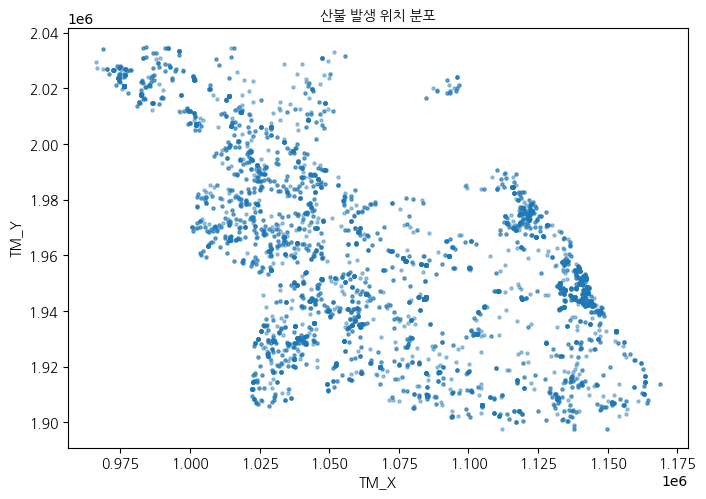

In [ ]:
# 좌표 결측 제거
fire_geo = fire_2000.dropna(subset=["TM_X", "TM_Y"]).copy()

# TM 좌표를 공간 데이터로 변환
fire_gdf = gpd.GeoDataFrame(
    fire_geo,
    geometry=gpd.points_from_xy(fire_geo["TM_X"], fire_geo["TM_Y"]),
    crs="EPSG:5179"
)

plt.figure(figsize=(8, 8))

ax = fire_gdf.plot(
    markersize=5,
    alpha=0.4,
    figsize=(8, 8)
)

apply_korean_font(
    ax=ax,
    title="산불 발생 위치 분포",
    xlabel="TM_X",
    ylabel="TM_Y"
)

plt.show()

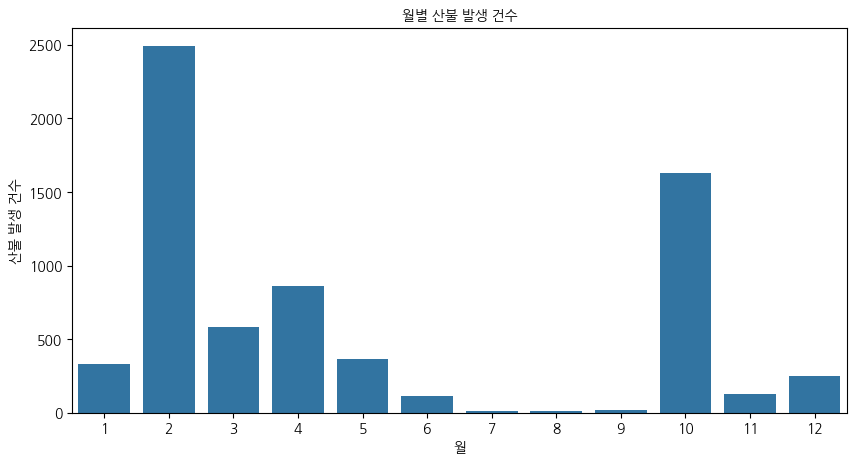

In [ ]:
monthly_fire_count = fire_2000.groupby("month").size().reset_index(name="fire_count")

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=monthly_fire_count,
    x="month",
    y="fire_count"
)

apply_korean_font(
    ax=ax,
    title="월별 산불 발생 건수",
    xlabel="월",
    ylabel="산불 발생 건수"
)

plt.show()

월별 산불 발생 건수를 확인한 결과, 2월과 10월의 발생 건수가 특히 높게 나타났다. 또한 3~5월에도 산불 발생이 비교적 많이 확인되어, 산불 발생이 특정 계절에 집중되는 경향을 보였다.

In [ ]:
# 월별 평균 기상 위험점수
monthly_weather_risk = weather.groupby("month")["weather_risk_score"].mean().reset_index()

# 월별 산불 발생건수와 결합
monthly_fire_weather = monthly_fire_count.merge(
    monthly_weather_risk,
    on="month",
    how="left"
)

monthly_fire_weather

,month,fire_count,weather_risk_score
0,1,333,0.446265
1,2,2492,0.456206
2,3,584,0.510727
3,4,862,0.545724
4,5,368,0.583584
5,6,117,0.509447
6,7,13,0.471974
7,8,9,0.505219
8,9,21,0.472523
9,10,1632,0.491493


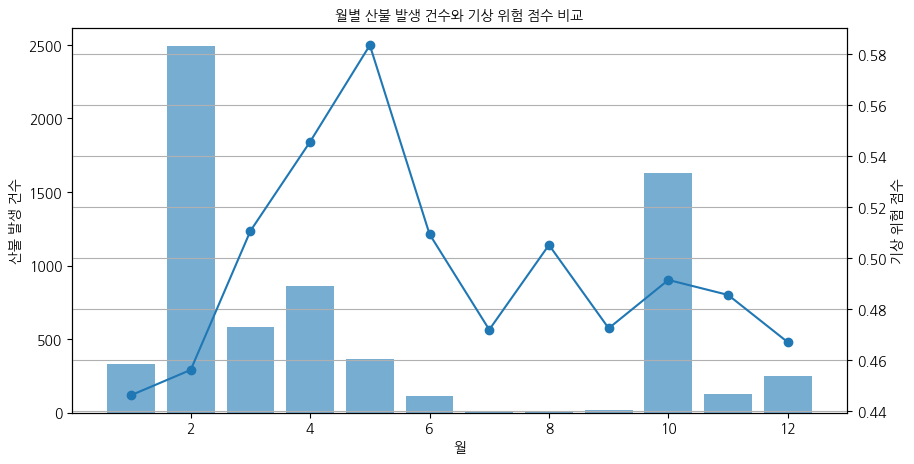

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# 산불 발생 건수
ax1.bar(
    monthly_fire_weather["month"],
    monthly_fire_weather["fire_count"],
    alpha=0.6,
    label="산불 발생 건수"
)

ax1.set_xlabel("월", fontproperties=font_prop)
ax1.set_ylabel("산불 발생 건수", fontproperties=font_prop)

# 기상 위험점수
ax2 = ax1.twinx()
ax2.plot(
    monthly_fire_weather["month"],
    monthly_fire_weather["weather_risk_score"],
    marker="o",
    label="기상 위험 점수"
)

ax2.set_ylabel("기상 위험 점수", fontproperties=font_prop)

# 제목
ax1.set_title("월별 산불 발생 건수와 기상 위험 점수 비교", fontproperties=font_prop)

# tick 한글 폰트 적용
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontproperties(font_prop)

for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)

plt.grid()
plt.show()

월별 기상 위험 점수는 4~5월에 높게 나타났지만, 산불 발생 건수는 2월과 10월에 가장 많았다. 따라서 기상 위험 점수만으로 산불 발생 건수를 설명하기에는 한계가 있으며, 인위적 발화 원인, 지역 특성, 기록 방식 등 추가 요인이 함께 고려되어야 한다

###시군구별 산불 발생 건수

In [ ]:
sgng_fire = fire_2000.groupby("SGNG_NM").agg(
    fire_count=("SGNG_NM", "size"),
    damage_area=("DMG_AREA", "sum"),
    mean_x=("TM_X", "mean"),
    mean_y=("TM_Y", "mean")
).reset_index()

sgng_fire = sgng_fire.dropna(subset=["mean_x", "mean_y"])

sgng_fire = sgng_fire.sort_values("fire_count", ascending=False)

sgng_fire.head(20)

,SGNG_NM,fire_count,damage_area,mean_x,mean_y
6,동해시,954,0.00,1.140184e+06,1.947541e+06
37,평창군,668,0.00,1.084239e+06,1.950405e+06
20,원주시,566,0.00,1.036048e+06,1.926062e+06
39,홍천군,508,0.00,1.035607e+06,1.968491e+06
29,철원군,466,0.00,9.813451e+05,2.022454e+06
17,영월군,462,0.00,1.088423e+06,1.912232e+06
43,횡성군,460,0.00,1.053215e+06,1.943423e+06
1,강릉시,392,0.00,1.121573e+06,1.972874e+06
10,삼척시,348,0.00,1.148429e+06,1.924654e+06
41,화천군,348,0.00,1.011877e+06,2.010352e+06


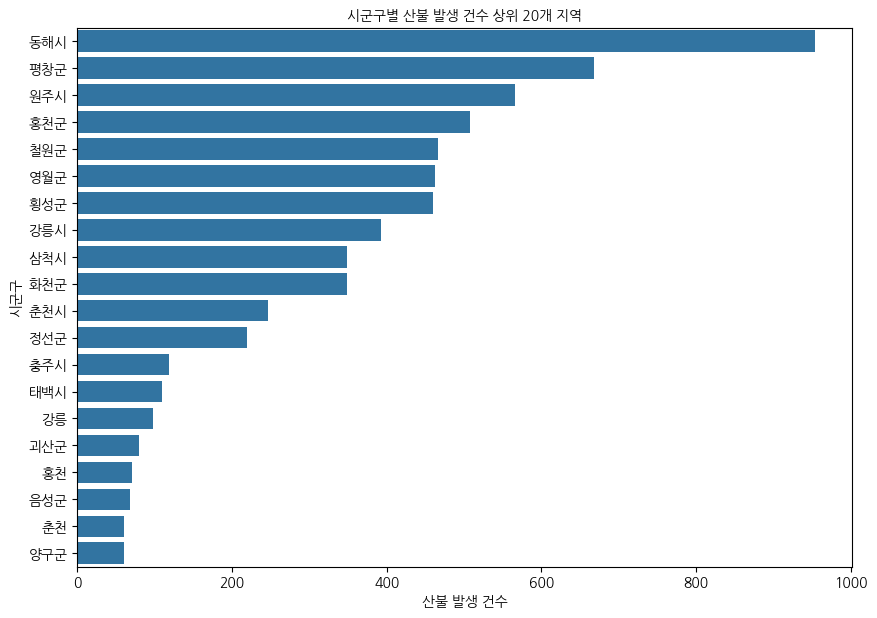

In [ ]:
plt.figure(figsize=(10, 7))

top20_sgng = sgng_fire.head(20)

ax = sns.barplot(
    data=top20_sgng,
    x="fire_count",
    y="SGNG_NM"
)

apply_korean_font(
    ax=ax,
    title="시군구별 산불 발생 건수 상위 20개 지역",
    xlabel="산불 발생 건수",
    ylabel="시군구"
)

plt.show()

시군구별로 산불 발생 건수와 피해면적을 집계하였다. 결과를 보면 동해시가 954건으로 가장 많고, 다음으로 평창군 668건, 원주시 566건, 홍천군 508건, 철원군 466건, 영월군 462건, 횡성군 460건 순으로 높게 나타났다.

이 결과는 산불 발생이 모든 지역에 고르게 분포하지 않고, 특정 시군구에 집중되어 있음을 보여준다.

다만 동해시와 동해, 강릉시와 강릉이 따로 잡힌 점은 주의해야한다.

###Moran’s I 전역 자기상관 분석

In [ ]:
!pip install -q libpysal esda

In [ ]:
from libpysal.weights import KNN
from esda.moran import Moran

In [ ]:
# 시군구별 대표 좌표를 이용해 GeoDataFrame 생성
sgng_gdf = gpd.GeoDataFrame(
    sgng_fire,
    geometry=gpd.points_from_xy(sgng_fire["mean_x"], sgng_fire["mean_y"]),
    crs="EPSG:5179"
)

# 공간 가중치: 가까운 5개 지역 기준
w = KNN.from_dataframe(sgng_gdf, k=5)
w.transform = "r"

# Moran's I: 산불 발생 건수 기준
moran_count = Moran(sgng_gdf["fire_count"], w)

print("Moran's I:", moran_count.I)
print("p-value:", moran_count.p_sim)

Moran's I: -0.04395818660049582
p-value: 0.458


Moran’s I 값은 -0.044로 0에 가까웠고, p-value는 0.458로 유의수준 0.05보다 컸다. 따라서 시군구별 산불 발생 건수는 전체적으로 유의한 공간적 자기상관을 보이지 않았다. 즉, 산불 발생 건수가 높은 지역들이 전역적으로 뚜렷하게 군집되어 있다고 해석하기는 어렵다.

###Local Moran LISA 분석

In [ ]:
from esda.moran import Moran_Local

In [ ]:
lisa = Moran_Local(sgng_gdf["fire_count"], w)

sgng_gdf["local_I"] = lisa.Is
sgng_gdf["local_p"] = lisa.p_sim
sgng_gdf["quadrant"] = lisa.q
sgng_gdf["significant"] = sgng_gdf["local_p"] < 0.05

def lisa_cluster(row):
    if row["significant"] == False:
        return "Not significant"
    elif row["quadrant"] == 1:
        return "High-High"
    elif row["quadrant"] == 2:
        return "Low-High"
    elif row["quadrant"] == 3:
        return "Low-Low"
    elif row["quadrant"] == 4:
        return "High-Low"

sgng_gdf["lisa_cluster"] = sgng_gdf.apply(lisa_cluster, axis=1)

sgng_gdf[["SGNG_NM", "fire_count", "local_I", "local_p", "lisa_cluster"]].sort_values("fire_count", ascending=False)

,SGNG_NM,fire_count,local_I,local_p,lisa_cluster
6,동해시,954,0.427826,0.279,Not significant
37,평창군,668,-1.049395,0.200,Not significant
20,원주시,566,-1.086410,0.054,Not significant
39,홍천군,508,-0.284663,0.421,Not significant
29,철원군,466,-0.311926,0.362,Not significant
17,영월군,462,0.278849,0.293,Not significant
43,횡성군,460,-0.061251,0.458,Not significant
1,강릉시,392,0.502567,0.135,Not significant
10,삼척시,348,0.293214,0.196,Not significant
41,화천군,348,-0.200836,0.330,Not significant


<Figure size 800x800 with 0 Axes>

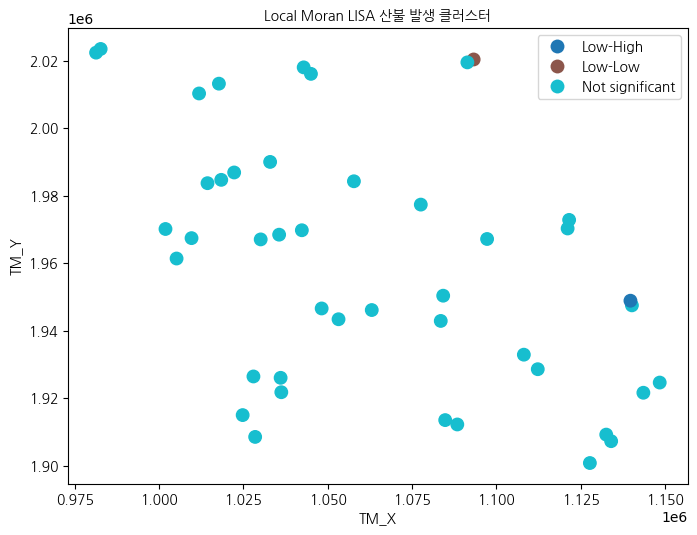

In [ ]:
plt.figure(figsize=(8, 8))

ax = sgng_gdf.plot(
    column="lisa_cluster",
    categorical=True,
    legend=True,
    figsize=(8, 8),
    markersize=80
)

apply_korean_font(
    ax=ax,
    title="Local Moran LISA 산불 발생 클러스터",
    xlabel="TM_X",
    ylabel="TM_Y"
)

plt.show()

Local Moran’s I 분석 결과, 대부분의 시군구는 통계적으로 유의한 공간 클러스터로 분류되지 않았다. 다만 속초시는 Low-Low 유형으로 나타나 주변 지역과 함께 산불 발생 건수가 낮은 공간적 패턴을 보였다. 전체적으로는 특정 고위험 지역이 주변 고위험 지역과 함께 군집되는 High-High 패턴은 뚜렷하지 않았다.

LISA 분석 결과를 지도 형태로 시각화하였다. 대부분의 지역이 Not significant로 분류되었기 때문에, 뚜렷한 고위험 핫스팟보다는 일부 저위험 클러스터만 확인되는 형태라고 해석하면 된다.

###Getis-Ord Gi* 핫스팟 분석

In [ ]:
from esda.getisord import G_Local
from libpysal.weights import KNN

In [ ]:
from esda.getisord import G_Local
from libpysal.weights import KNN
import numpy as np
import pandas as pd

# Gi* 분석용 데이터 따로 만들기
sgng_gdf_gi = sgng_gdf.copy()

# fire_count를 확실하게 숫자형으로 변환
sgng_gdf_gi["fire_count"] = pd.to_numeric(
    sgng_gdf_gi["fire_count"],
    errors="coerce"
)

# geometry와 fire_count 결측 제거
sgng_gdf_gi = sgng_gdf_gi.dropna(
    subset=["fire_count", "geometry"]
).copy()

# 인덱스 초기화
sgng_gdf_gi = sgng_gdf_gi.reset_index(drop=True)

# fire_count를 numpy float64 배열로 확실하게 변환
y_gi = sgng_gdf_gi["fire_count"].astype(np.float64).to_numpy()

# 공간가중치 다시 생성
w_gi = KNN.from_dataframe(sgng_gdf_gi, k=5)
w_gi.transform = "r"

# Getis-Ord Gi* 계산
gi = G_Local(
    y_gi,
    w_gi,
    permutations=999,
    n_jobs=1
)

# 결과 저장
sgng_gdf_gi["gi_z_score"] = gi.Zs
sgng_gdf_gi["gi_p_value"] = gi.p_sim

sgng_gdf_gi[["SGNG_NM", "fire_count", "gi_z_score", "gi_p_value"]].head()

,SGNG_NM,fire_count,gi_z_score,gi_p_value
0,동해시,954,0.243834,0.285
1,평창군,668,-0.426438,0.180
2,원주시,566,-0.564637,0.036
3,홍천군,508,-0.145517,0.419
4,철원군,466,-0.193461,0.348


In [ ]:
def gi_hotspot(row):
    if row["gi_p_value"] < 0.01 and row["gi_z_score"] > 0:
        return "Hotspot 99%"
    elif row["gi_p_value"] < 0.05 and row["gi_z_score"] > 0:
        return "Hotspot 95%"
    elif row["gi_p_value"] < 0.10 and row["gi_z_score"] > 0:
        return "Hotspot 90%"
    elif row["gi_p_value"] < 0.05 and row["gi_z_score"] < 0:
        return "Coldspot"
    else:
        return "Not significant"

sgng_gdf_gi["gi_cluster"] = sgng_gdf_gi.apply(gi_hotspot, axis=1)

sgng_gdf_gi[
    ["SGNG_NM", "fire_count", "gi_z_score", "gi_p_value", "gi_cluster"]
].sort_values("gi_z_score", ascending=False).head(20)

,SGNG_NM,fire_count,gi_z_score,gi_p_value,gi_cluster
32,동해,18,0.954662,0.032,Hotspot 95%
23,횡성,35,0.745844,0.066,Hotspot 90%
14,강릉,98,0.728736,0.074,Hotspot 90%
20,삼척,48,0.582570,0.110,Not significant
22,영월,43,0.569501,0.112,Not significant
7,강릉시,392,0.500155,0.133,Not significant
41,거창군,4,0.434066,0.167,Not significant
11,정선군,220,0.426789,0.168,Not significant
43,익산,1,0.377464,0.195,Not significant
8,삼척시,348,0.358995,0.199,Not significant


Gi* 분석 결과 일부 지역의 z-score와 p-value를 확인하였다. 예를 들어 출력 상위 일부에서는 동해시가 발생 건수는 954건으로 많지만, Gi* 기준에서는 p-value가 0.285로 유의하지 않았다. 원주시는 z-score가 음수이고 p-value가 0.036으로 나타나지만, 이는 고위험 핫스팟이 아니라 낮은 방향의 공간 패턴에 가까운 결과이다.

즉 단순히 발생 건수가 많다고 해서 반드시 공간적 핫스팟으로 분류되지는 않는다는 점을 보여준다.

<Figure size 800x800 with 0 Axes>

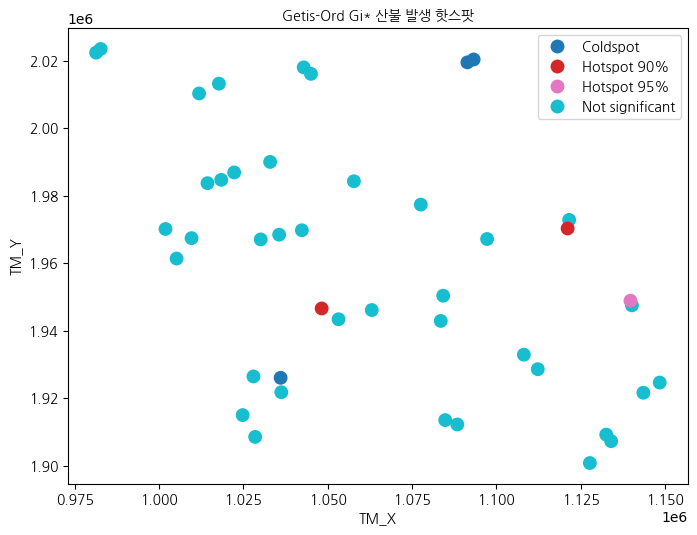

In [ ]:
plt.figure(figsize=(8, 8))

ax = sgng_gdf_gi.plot(
    column="gi_cluster",
    categorical=True,
    legend=True,
    figsize=(8, 8),
    markersize=80
)

apply_korean_font(
    ax=ax,
    title="Getis-Ord Gi* 산불 발생 핫스팟",
    xlabel="TM_X",
    ylabel="TM_Y"
)

plt.show()

Getis-Ord Gi* 분석 결과 일부 지역이 핫스팟으로 분류되었으나, 전체적으로는 유의한 핫스팟 지역이 제한적으로 나타났다. 이는 산불 발생이 특정 지역에만 강하게 집중되기보다는 여러 지역에 분산되어 나타날 가능성을 시사한다.

In [ ]:
# 핫스팟 여부: Hotspot이면 1, 아니면 0
sgng_gdf_gi["hotspot_binary"] = np.where(
    sgng_gdf_gi["gi_cluster"].str.contains("Hotspot"),
    1,
    0
)

# 핫스팟 등급 점수화
cluster_score_map = {
    "Hotspot 99%": 3,
    "Hotspot 95%": 2,
    "Hotspot 90%": 1,
    "Not significant": 0,
    "Coldspot": -1
}

sgng_gdf_gi["hotspot_grade"] = sgng_gdf_gi["gi_cluster"].map(cluster_score_map)

# 인접성 점수: 주변 지역의 평균적 산불 발생 수준
sgng_gdf_gi["neighbor_fire_score"] = w_gi.sparse.dot(
    sgng_gdf_gi["fire_count"].values
)

sgng_gdf_gi[
    [
        "SGNG_NM",
        "fire_count",
        "gi_cluster",
        "hotspot_binary",
        "hotspot_grade",
        "neighbor_fire_score"
    ]
].sort_values("hotspot_grade", ascending=False).head(20)

,SGNG_NM,fire_count,gi_cluster,hotspot_binary,hotspot_grade,neighbor_fire_score
32,동해,18,Hotspot 95%,1,2,368.0
14,강릉,98,Hotspot 90%,1,1,317.0
23,횡성,35,Hotspot 90%,1,1,321.8
0,동해시,954,Not significant,0,0,180.8
8,삼척시,348,Not significant,0,0,228.8
5,영월군,462,Not significant,0,0,199.0
6,횡성군,460,Not significant,0,0,144.8
7,강릉시,392,Not significant,0,0,258.2
10,춘천시,246,Not significant,0,0,167.0
1,평창군,668,Not significant,0,0,54.6


In [ ]:
# 피해면적 결측값 처리
fire_2000["DMG_AREA"] = pd.to_numeric(
    fire_2000["DMG_AREA"],
    errors="coerce"
).fillna(0)

def damage_grade(area):
    if area == 0:
        return "피해없음/미상"
    elif area < 1:
        return "낮음"
    elif area < 10:
        return "보통"
    else:
        return "높음"

fire_2000["damage_risk_grade"] = fire_2000["DMG_AREA"].apply(damage_grade)

fire_2000[
    ["fire_date", "SGNG_NM", "DMG_AREA", "damage_risk_grade"]
].head(20)

,fire_date,SGNG_NM,DMG_AREA,damage_risk_grade
375,2000-02-09 23:17:00,강릉,0.30,낮음
376,2000-02-10 00:41:00,강릉,2.00,보통
377,2000-02-10 01:16:00,강릉,1.50,보통
378,2000-02-10 15:00:00,평창,0.10,낮음
379,2000-02-15 03:31:00,강릉,0.03,낮음
380,2000-02-15 03:39:00,강릉,0.01,낮음
381,2000-02-15 04:29:00,강릉,0.03,낮음
382,2000-02-15 04:39:00,강릉,0.07,낮음
383,2000-02-16 16:55:00,삼척,0.70,낮음
384,2000-02-17 14:38:00,강릉,0.05,낮음


In [ ]:
# 연도-월별 산불 발생 건수 집계
monthly_fire_label = fire_2000.groupby(["year", "month"]).size().reset_index(name="fire_count")

# 산불 발생 여부 label
monthly_fire_label["fire_label"] = np.where(
    monthly_fire_label["fire_count"] > 0,
    1,
    0
)

monthly_fire_label.head()

,year,month,fire_count,fire_label
0,2000,2,27,1
1,2000,3,36,1
2,2000,4,38,1
3,2000,5,5,1
4,2000,6,1,1


###정리

분석에서는 2000년부터 2022년까지의 기상 데이터와 산불 발생 위치 데이터를 활용하여 산불 위험과 관련된 기상적·공간적 패턴을 탐색하였다. 먼저 기상 데이터의 기본 구조, 결측치, 변수 분포, 이상치, 계절성을 확인하였고, 이후 최고기온, 최대순간풍속, 월강수량합을 활용하여 기상 기반 산불 위험 점수인 weather_risk_score를 생성하였다.

기상 데이터 EDA 결과, 평균상대습도는 결측률이 매우 높아 주요 분석 변수로 활용하기에는 한계가 있었다. 반면 기온, 풍속, 강수량 변수는 비교적 활용 가능성이 높았으며, 산불 위험과 관련된 고온·강풍·저강수 조건을 파악하는 데 사용하였다. 월별 분석에서는 기상 위험 점수가 4~5월에 높게 나타났으며, 이는 봄철에 산불 위험 기상 조건이 강하게 형성될 가능성을 보여준다.

이후 산불 발생 위치 데이터를 결합하여 실제 산불 발생의 시간적·공간적 패턴을 확인하였다. 월별 산불 발생 건수를 분석한 결과, 산불 발생은 2월과 10월에 특히 높게 나타났고, 3-5월에도 비교적 많이 발생하였다. 그러나 기상 위험 점수는 4-5월에 가장 높게 나타났기 때문에, 기상 위험 조건이 실제 산불 발생 시기와 완전히 일치하지는 않았다. 이는 산불 발생이 단순히 기상 조건만으로 설명되기보다는 인위적 발화 원인, 지역 특성, 지형, 산림 분포, 데이터 기록 방식 등 다양한 요인의 영향을 받는다는 점을 시사한다.

공간적으로는 산불 발생 좌표를 활용하여 산불 발생 위치를 시각화하고, 시군구별 산불 발생 건수와 피해면적을 집계하였다. 그 결과 동해시, 평창군, 원주시, 홍천군 등 일부 지역에서 산불 발생 건수가 높게 나타났다. 이는 산불 발생이 지역별로 균등하게 분포하지 않고 특정 지역에 상대적으로 집중되는 경향이 있음을 보여준다.

공간 자기상관 분석에서는 Moran’s I를 활용하여 시군구별 산불 발생 건수가 전역적으로 군집되어 있는지 확인하였다. 분석 결과 Moran’s I 값은 0에 가깝고 p-value도 유의수준보다 크게 나타나, 전체적으로 뚜렷한 전역적 공간 자기상관은 확인되지 않았다. 즉, 산불 발생 건수가 높은 지역들이 전체적으로 서로 인접하여 강하게 군집되어 있다고 보기는 어려웠다.

Local Moran’s I와 Getis-Ord Gi* 분석을 통해 국지적 클러스터와 핫스팟도 확인하였다. 대부분의 지역은 통계적으로 유의한 클러스터로 분류되지 않았으며, 일부 지역만 핫스팟 가능성을 보였다. 따라서 산불 발생이 특정 지역에 강하게 집중된다고 단정하기보다는, 일부 지역에서 제한적으로 공간적 위험 패턴이 나타난다고 해석하는 것이 적절하다.

마지막으로 공간분석 결과를 바탕으로 hotspot_binary, hotspot_grade, neighbor_fire_score와 같은 파생변수를 생성하였다. 또한 산불 피해면적을 기준으로 피해 위험등급을 만들고, 연도-월별 산불 발생 여부 label을 생성하였다. 이를 통해 향후 산불 발생 예측 모델이나 위험도 분류 모델에 사용할 수 있는 기초 target 및 설명변수를 구성하였다.